In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("./Ames_outliers_removed.csv")
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [2]:
df.drop("PID",axis=1,inplace=True)
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
def percent_missing(df):
    p_nan = df.isnull().sum() / len(df) * 100
    p_nan = p_nan[p_nan > 0].sort_values(ascending=False)
    return p_nan
p_nan = percent_missing(df)
p_nan

Pool QC           99.590024
Misc Feature      96.412709
Alley             93.235395
Fence             80.457807
Mas Vnr Type      60.642296
Fireplace Qu      48.582166
Lot Frontage      16.740690
Garage Qual        5.432183
Garage Cond        5.432183
Garage Yr Blt      5.432183
Garage Finish      5.432183
Garage Type        5.363854
Bsmt Exposure      2.835668
BsmtFin Type 2     2.767339
Bsmt Cond          2.733174
Bsmt Qual          2.733174
BsmtFin Type 1     2.733174
Mas Vnr Area       0.785787
Bsmt Full Bath     0.068329
Bsmt Half Bath     0.068329
BsmtFin SF 1       0.034165
BsmtFin SF 2       0.034165
Electrical         0.034165
Total Bsmt SF      0.034165
Bsmt Unf SF        0.034165
Garage Area        0.034165
Garage Cars        0.034165
dtype: float64

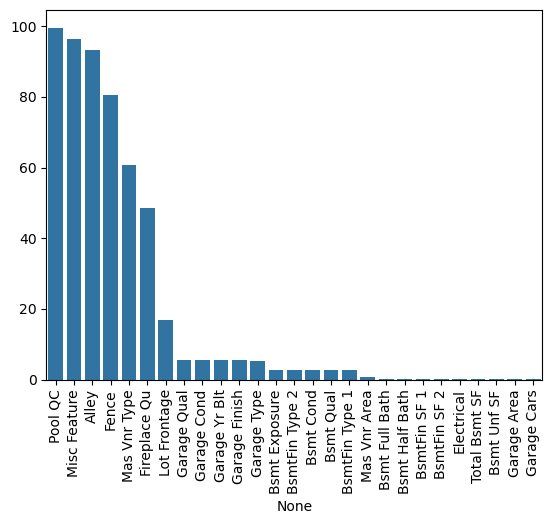

In [4]:
sns.barplot(x = p_nan.index,y=p_nan.values)
plt.xticks(rotation=90)
plt.show()

In [5]:
p_nan[p_nan < 1]

Mas Vnr Area      0.785787
Bsmt Full Bath    0.068329
Bsmt Half Bath    0.068329
BsmtFin SF 1      0.034165
BsmtFin SF 2      0.034165
Electrical        0.034165
Total Bsmt SF     0.034165
Bsmt Unf SF       0.034165
Garage Area       0.034165
Garage Cars       0.034165
dtype: float64

In [6]:
df[df["Total Bsmt SF"].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000


In [7]:
df[df["Bsmt Full Bath"].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


- BsmtFin SF 1：地下室完成面積 1
- BsmtFin SF 2：地下室完成面積 2
- Bsmt Unf SF：地下室未完成面積
- Total Bsmt SF：總地下室面積
- Bsmt Full Bath：地下室全浴室數量
- Bsmt Half Bath：地下室半浴室數量

In [9]:
bsmt_num_cols = ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF','Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath']
df[bsmt_num_cols] = df[bsmt_num_cols].fillna(0)

In [10]:
p_nan = percent_missing(df)
p_nan

Pool QC           99.590024
Misc Feature      96.412709
Alley             93.235395
Fence             80.457807
Mas Vnr Type      60.642296
Fireplace Qu      48.582166
Lot Frontage      16.740690
Garage Finish      5.432183
Garage Yr Blt      5.432183
Garage Cond        5.432183
Garage Qual        5.432183
Garage Type        5.363854
Bsmt Exposure      2.835668
BsmtFin Type 2     2.767339
Bsmt Qual          2.733174
BsmtFin Type 1     2.733174
Bsmt Cond          2.733174
Mas Vnr Area       0.785787
Electrical         0.034165
Garage Area        0.034165
Garage Cars        0.034165
dtype: float64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2927 entries, 0 to 2926
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2927 non-null   int64  
 1   MS Zoning        2927 non-null   str    
 2   Lot Frontage     2437 non-null   float64
 3   Lot Area         2927 non-null   int64  
 4   Street           2927 non-null   str    
 5   Alley            198 non-null    str    
 6   Lot Shape        2927 non-null   str    
 7   Land Contour     2927 non-null   str    
 8   Utilities        2927 non-null   str    
 9   Lot Config       2927 non-null   str    
 10  Land Slope       2927 non-null   str    
 11  Neighborhood     2927 non-null   str    
 12  Condition 1      2927 non-null   str    
 13  Condition 2      2927 non-null   str    
 14  Bldg Type        2927 non-null   str    
 15  House Style      2927 non-null   str    
 16  Overall Qual     2927 non-null   int64  
 17  Overall Cond     2927 non

In [13]:
df["Mas Vnr Type"] = df["Mas Vnr Type"].fillna("None")
df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(0)

In [14]:
p_nan = percent_missing(df)
p_nan

Pool QC           99.590024
Misc Feature      96.412709
Alley             93.235395
Fence             80.457807
Fireplace Qu      48.582166
Lot Frontage      16.740690
Garage Finish      5.432183
Garage Cond        5.432183
Garage Yr Blt      5.432183
Garage Qual        5.432183
Garage Type        5.363854
Bsmt Exposure      2.835668
BsmtFin Type 2     2.767339
Bsmt Qual          2.733174
Bsmt Cond          2.733174
BsmtFin Type 1     2.733174
Electrical         0.034165
Garage Area        0.034165
Garage Cars        0.034165
dtype: float64

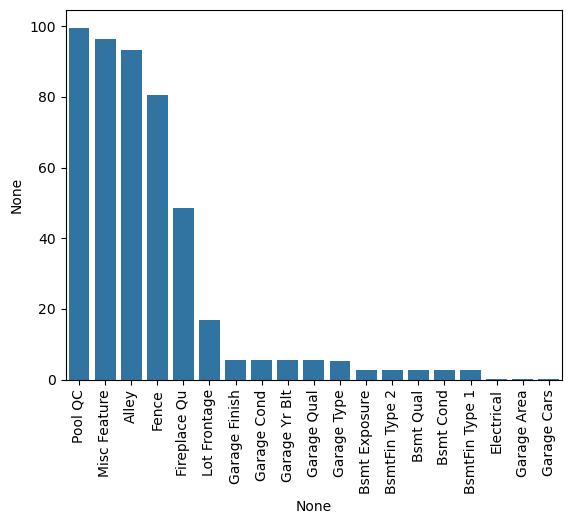

In [15]:
p_nan = percent_missing(df)
sns.barplot(x = p_nan.index,y = p_nan)
plt.xticks(rotation=90)
plt.show()

In [16]:
df[["Garage Type","Garage Finish","Garage Qual","Garage Cond"]]

,Garage Type,Garage Finish,Garage Qual,Garage Cond
0,Attchd,Fin,TA,TA
1,Attchd,Unf,TA,TA
2,Attchd,Unf,TA,TA
3,Attchd,Fin,TA,TA
4,Attchd,Fin,TA,TA
...,...,...,...,...
2922,Detchd,Unf,TA,TA
2923,Attchd,Unf,TA,TA
2924,NaN,NaN,NaN,NaN
2925,Attchd,RFn,TA,TA


In [17]:
df[["Garage Yr Blt"]]

,Garage Yr Blt
0,1960.0
1,1961.0
2,1958.0
3,1968.0
4,1997.0
...,...
2922,1984.0
2923,1983.0
2924,NaN
2925,1975.0


In [18]:
gar_str_clos = ["Garage Type","Garage Finish","Garage Qual","Garage Cond"]
df[gar_str_clos] = df[gar_str_clos].fillna("None")

In [19]:
df[["Garage Yr Blt"]] = df[["Garage Yr Blt"]].fillna(0)

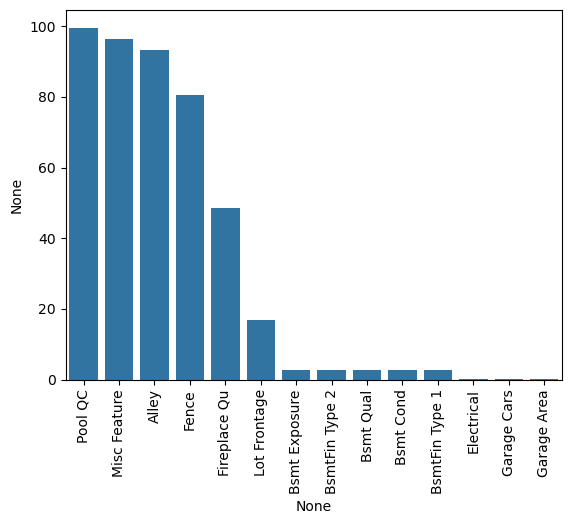

In [20]:
p_nan = percent_missing(df)
sns.barplot(x = p_nan.index,y = p_nan)
plt.xticks(rotation=90)
plt.show()

In [21]:
df.dropna(axis=0,subset=["Electrical","Garage Cars"],inplace=True)

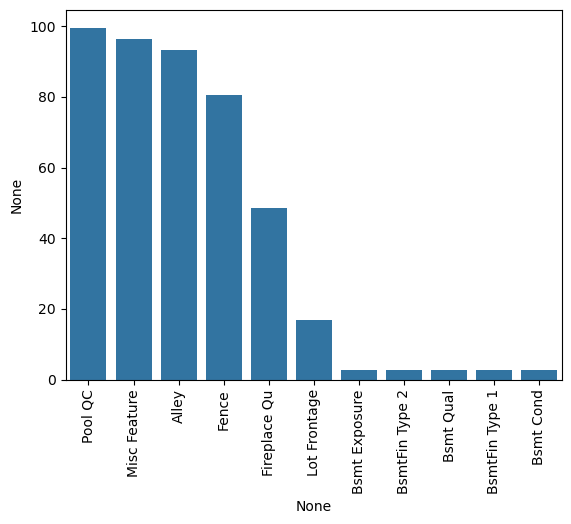

In [22]:
p_nan = percent_missing(df)
sns.barplot(x = p_nan.index,y = p_nan)
plt.xticks(rotation=90)
plt.show()

In [23]:
bsmt_str_cols = ["Bsmt Qual","Bsmt Cond","Bsmt Exposure","BsmtFin Type 1","BsmtFin Type 2"]
df[bsmt_str_cols]

,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2
0,TA,Gd,Gd,BLQ,Unf
1,TA,TA,No,Rec,LwQ
2,TA,TA,No,ALQ,Unf
3,TA,TA,No,ALQ,Unf
4,Gd,TA,No,GLQ,Unf
...,...,...,...,...,...
2922,TA,TA,Av,GLQ,Unf
2923,Gd,TA,Av,BLQ,ALQ
2924,Gd,TA,Av,GLQ,Unf
2925,Gd,TA,Av,ALQ,LwQ


In [24]:
df[bsmt_str_cols] = df[bsmt_str_cols].fillna("None")

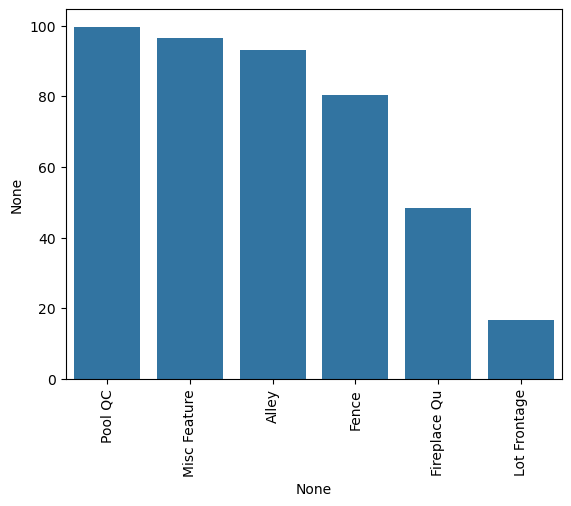

In [25]:
p_nan = percent_missing(df)
sns.barplot(x = p_nan.index,y = p_nan)
plt.xticks(rotation=90)
plt.show()

In [26]:
p_nan = percent_missing(df)
p_nan

Pool QC         99.589744
Misc Feature    96.410256
Alley           93.230769
Fence           80.478632
Fireplace Qu    48.547009
Lot Frontage    16.752137
dtype: float64

In [27]:
df = df.drop(["Pool QC","Misc Feature","Alley","Fence"],axis=1)

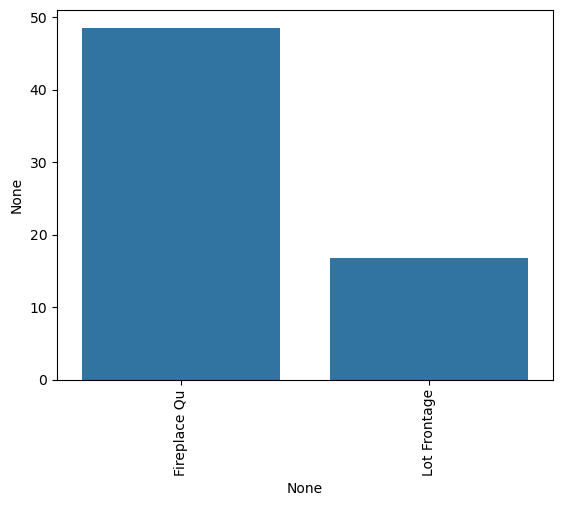

In [28]:
p_nan = percent_missing(df)
sns.barplot(x = p_nan.index,y = p_nan)
plt.xticks(rotation=90)
plt.show()

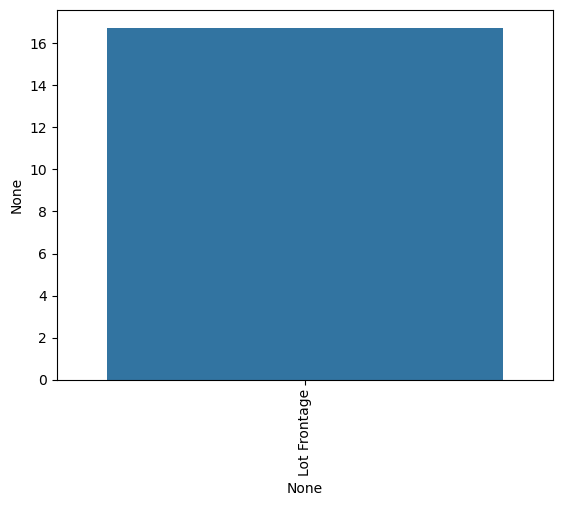

In [29]:
df["Fireplace Qu"] = df["Fireplace Qu"].fillna("None")
p_nan = percent_missing(df)
sns.barplot(x = p_nan.index,y = p_nan)
plt.xticks(rotation=90)
plt.show()

這些名字代表的是阿姆斯市（Ames, Iowa）內的不同社區或鄰里。在房地產數據中，`Neighborhood` 指的是房產所在的地理位置，每個名稱代表一個特定的區域。這些不同的社區可能會有不同的房價、地段特性、居民組成以及生活設施等特點。

以下是一些具體的鄰里名稱和可能的簡介：

- **NAmes**: 通常是指 North Ames，可能是位於阿姆斯北部的一個住宅區。
- **Gilbert**: 可能是一個以家庭為主的社區。
- **StoneBr**: 簡稱 Stone Bridge，可能是一個較新的或高檔的住宅區。
- **NWAmes**: 指 Northwest Ames，指的是阿姆斯西北部的一個區域。
- **Somerst**: 可能指的是 Somerst 社區，這是一個受歡迎的住宅區。
- **BrDale**: 可能是 Brookdale 的縮寫，指的是一個特定的住宅區。
- **NPkVill**: North Park Village 的縮寫，可能是一個小型社區。
- **NridgHt**: Northridge Heights 的縮寫，通常是高檔住宅區。
- **Blmngtn**: Bloomington 的縮寫，可能是一個家庭型社區。
- **NoRidge**: North Ridge，一個可能擁有優越景觀的區域。
- **SawyerW**: Sawyer West，Sawyer 社區的一部分。
- **Sawyer**: 一個可能中等價位的住宅區。
- **Greens**: 可能是一個小型或專門的住宅區。
- **BrkSide**: Brookside，可能是一個歷史悠久的區域。
- **OldTown**: 老城區，通常是城市的老區域，有很多歷史建築。
- **IDOTRR**: Interstate Department of Transportation Railroad，可能是一個靠近鐵路的工業區。
- **ClearCr**: Clear Creek，一個可能靠近溪流的自然美景區。
- **SWISU**: South West Iowa State University，靠近愛荷華州立大學的西南部。
- **Edwards**: 可能是以開發者或地區歷史人物命名的社區。
- **CollgCr**: College Creek，可能是學生或大學教職工居住的區域。
- **Crawfor**: Crawford，可能是一個以家庭為主的社區。
- **Blueste**: Bluestem，可能是一個新開發的住宅區。
- **Mitchel**: 可能是一個家庭型社區。
- **Timber**: 可能是一個擁有豐富樹木的區域。
- **MeadowV**: Meadow Village，一個可能有開放空間的社區。
- **Veenker**: 可能是一個以高檔住宅為主的社區。
- **GrnHill**: Green Hill，可能是一個綠化很好的區域。
- **Landmrk**: Landmark area，一個可能具有地標性的區域。

這些社區的名稱有助於了解房產所處的位置和社區特色.

In [30]:
df["Neighborhood"].unique()

<ArrowStringArray>
[  'NAmes', 'Gilbert', 'StoneBr',  'NWAmes', 'Somerst',  'BrDale', 'NPkVill',
 'NridgHt', 'Blmngtn', 'NoRidge', 'SawyerW',  'Sawyer',  'Greens', 'BrkSide',
 'OldTown',  'IDOTRR', 'ClearCr',   'SWISU', 'Edwards', 'CollgCr', 'Crawfor',
 'Blueste', 'Mitchel',  'Timber', 'MeadowV', 'Veenker', 'GrnHill', 'Landmrk']
Length: 28, dtype: str

In [31]:
group = df.groupby("Neighborhood")["Lot Frontage"]
print(list(group))

[('Blmngtn', 52      43.0
53      43.0
468     53.0
469     51.0
470     43.0
471     43.0
472     43.0
473     43.0
1080     NaN
1081     NaN
1082    43.0
1083    43.0
1084    53.0
1740    53.0
1741    53.0
1742     NaN
1743    53.0
2416    43.0
2417     NaN
2418     NaN
2419     NaN
2420     NaN
2421     NaN
2422    43.0
2423    43.0
2424    43.0
2425    53.0
2426    53.0
Name: Lot Frontage, dtype: float64), ('Blueste', 298     35.0
299     35.0
932     24.0
933     24.0
934     24.0
935     24.0
1541    24.0
1542    24.0
2222    24.0
2224    35.0
Name: Lot Frontage, dtype: float64), ('BrDale', 29      21.0
30      21.0
31      21.0
402     21.0
403     24.0
404     21.0
405     21.0
406     21.0
407     21.0
1039    21.0
1040    21.0
1041    21.0
1042    21.0
1043    21.0
1044    21.0
1045    21.0
1674    21.0
1675    21.0
1676    21.0
1677    24.0
1678    24.0
2361    24.0
2362    24.0
2363    21.0
2364    21.0
2365    21.0
2366    21.0
2367    21.0
2368    21.0
2369    21.0
Name: 

In [35]:
group.mean()

Neighborhood
Blmngtn    46.900000
Blueste    27.300000
BrDale     21.500000
BrkSide    55.789474
ClearCr    88.150000
CollgCr    71.336364
Crawfor    69.951807
Edwards    64.794286
Gilbert    74.207207
Greens     41.000000
GrnHill          NaN
IDOTRR     62.383721
Landmrk          NaN
MeadowV    25.606061
Mitchel    75.144444
NAmes      75.210667
NPkVill    28.142857
NWAmes     81.517647
NoRidge    91.629630
NridgHt    84.184049
OldTown    61.777293
SWISU      59.068182
Sawyer     74.551020
SawyerW    70.669811
Somerst    64.549383
StoneBr    62.173913
Timber     81.303571
Veenker    72.000000
Name: Lot Frontage, dtype: float64

In [33]:
df[df["Lot Frontage"].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
11,20,RL,NaN,7980,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,500,3,2010,WD,Normal,185000
14,120,RL,NaN,6820,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,140,0,0,6,2010,WD,Normal,212000
22,60,FV,NaN,7500,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,1,2010,WD,Normal,216000
23,20,RL,NaN,11241,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,700,3,2010,WD,Normal,149000
24,20,RL,NaN,12537,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,149900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2891,20,RL,NaN,16669,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,1,2006,WD,Normal,228000
2894,60,RL,NaN,11170,Pave,IR2,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,4,2006,WD,Normal,250000
2895,20,RL,NaN,8098,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,10,2006,WD,Normal,202000
2909,90,RL,NaN,11836,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,3,2006,WD,Normal,146500


In [ ]:
df["Lot Frontage"] = group.transform(lambda x:x.fillna(x.mean()))


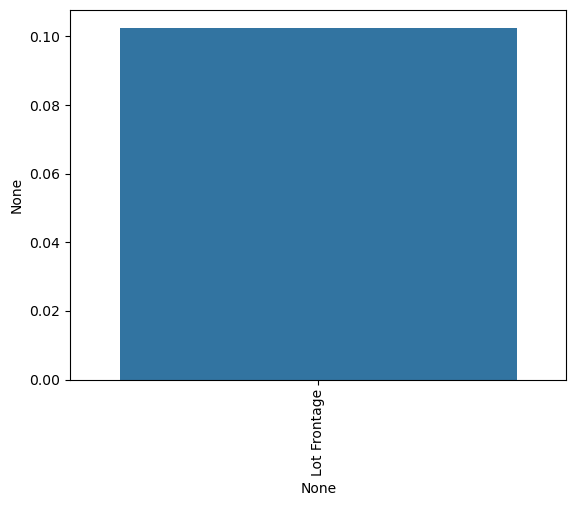

In [38]:
p_nan   = percent_missing(df)
sns.barplot(x = p_nan.index,y = p_nan)
plt.xticks(rotation=90)
plt.show()

In [39]:
df["Lot Frontage"] = df["Lot Frontage"].fillna(0)

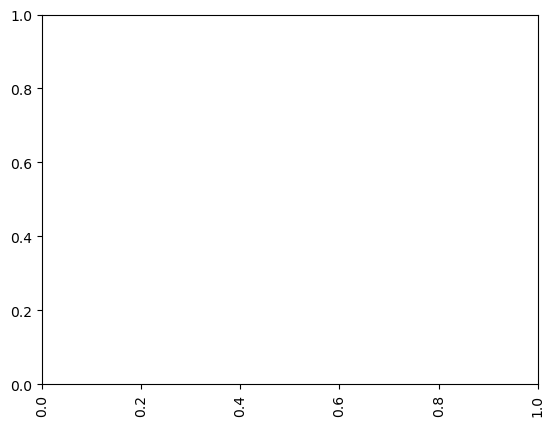

In [40]:
p_nan   = percent_missing(df)
sns.barplot(x = p_nan.index,y = p_nan)
plt.xticks(rotation=90)
plt.show()

### 為什麼需要 OneHotEncoder

1. **轉換類別變數**：
   - 類別變數不能直接用於大多數機器學習模型，需要將其轉換為數值型。
   - OneHotEncoder 將每個類別變數轉換為多個二進位變數，使模型能夠理解並利用這些特徵。

2. **避免引入順序關係**：
   - 將類別變數轉換為數字（如使用 LabelEncoder）可能會引入不必要的順序關係，而 OneHotEncoder 避免了這一點。
   - 保證了每個類別之間的獨立性，不會因為數值大小而影響模型的預測。

3. **提高模型性能**：
   - 對於很多模型來說，使用 OneHotEncoder 編碼後的特徵可以提高模型的性能，因為它能更好地表示數據的結構和模式。

原始資料如下:


### 原始資料

|    | Color |
|----|-------|
| 0  | Red   |
| 1  | Green |
| 2  | Blue  |
| 3  | Green |
| 4  | Red   |

### 把顏色對應到數字(LabelEncoder) 結果

|    | Color | Color_Label |
|----|-------|-------------|
| 0  | Red   | 2           |
| 1  | Green | 1           |
| 2  | Blue  | 0           |
| 3  | Green | 1           |
| 4  | Red   | 2           |

### OneHotEncoder 結果

|    | Color | Color_Red | Color_Green | Color_Blue |
|----|-------|-----------|-------------|------------|
| 0  | Red   | 1         | 0           | 0          |
| 1  | Green | 0         | 1           | 0          |
| 2  | Blue  | 0         | 0           | 1          |
| 3  | Green | 0         | 1           | 0          |
| 4  | Red   | 1         | 0           | 0          |

## LabelEncoder 

#### 將類別標籤轉換為數字編碼，適用於有順序關係的類別變數。

In [43]:
import pandas as pd
data = pd.DataFrame({"Fruits": ['Apple', 'Banana', 'Cherry', 'Kewi']})
#data
fruit_mappin = {"Apple":1,"Banana":2,"Cherry":3,"Kewi":4}
data["Fruit_number1"] = data["Fruits"].map(fruit_mappin)
data["Fruit_number2"] = data["Fruits"].apply(lambda x:fruit_mappin[x])
data

,Fruits,Fruit_number1,Fruit_number2
0,Apple,1,1
1,Banana,2,2
2,Cherry,3,3
3,Kewi,4,4


In [52]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
data = pd.DataFrame({
    'Fruits': ['Apple', 'Banana', 'Cherry', 'Kiwi','Cherry', 'Kiwi','Apple', 'Banana'],
})
oder = ["Kiwi","Apple","Banana","Cherry"]
enc = OrdinalEncoder(categories=[oder])
enc.fit(data[["Fruits"]])
data["Fruit_number"] = enc.transform(data[["Fruits"]]).astype(int)
data


,Fruits,Fruit_number
0,Apple,1
1,Banana,2
2,Cherry,3
3,Kiwi,0
4,Cherry,3
5,Kiwi,0
6,Apple,1
7,Banana,2


In [53]:
## OneHotEncoder
import pandas as pd
from sklearn.preprocessing import OneHotEncoder


In [54]:
# 建立一個範例 DataFrame
data = pd.DataFrame({
    'Color': ['Red', 'Green', 'Blue', 'Green', 'Red']
})

In [57]:
ohe = OneHotEncoder()
on_hot_code = ohe.fit_transform(data[['Color']])
print(on_hot_code)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (5, 3)>
  Coords	Values
  (0, 2)	1.0
  (1, 1)	1.0
  (2, 0)	1.0
  (3, 1)	1.0
  (4, 2)	1.0


In [ ]:
ohe = OneHotEncoder(sparse_output=False)
on_hot_code = ohe.fit_transform(data[['Color']])
print(on_hot_code)

[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [61]:
colName = ohe.get_feature_names_out()
print(colName)
pne_hot_df = pd.DataFrame(on_hot_code, columns=colName)
pne_hot_df

['Color_Blue' 'Color_Green' 'Color_Red']


,Color_Blue,Color_Green,Color_Red
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0


In [62]:
data = data.join(pne_hot_df)
data

,Color,Color_Blue,Color_Green,Color_Red
0,Red,0.0,0.0,1.0
1,Green,0.0,1.0,0.0
2,Blue,1.0,0.0,0.0
3,Green,0.0,1.0,0.0
4,Red,0.0,0.0,1.0


In [63]:
import pandas as pd
# 建立一個範例 DataFrame
data = pd.DataFrame({
    'Color': ['Red', 'Green', 'Blue', 'Green', 'Red']
})
one_hot_df = pd.get_dummies(data,columns=["Color"])
one_hot_df

,Color_Blue,Color_Green,Color_Red
0,False,False,True
1,False,True,False
2,True,False,False
3,False,True,False
4,False,False,True
